In [74]:
import functions
import importlib
from matplotlib import pyplot as plt
import cv2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
importlib.reload(functions)
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [75]:
imagens, imgs_mask, labels = functions.load_and_resize_images()

Total de imagens: 1023
Total de labels: 1023


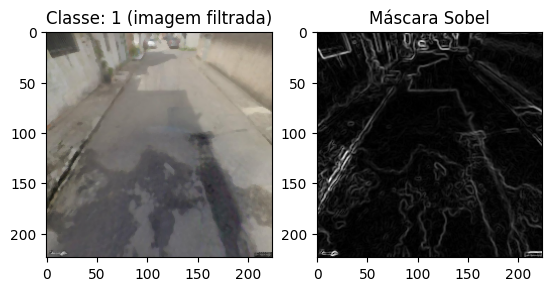

In [76]:
i = 500 # exemplo
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB))
plt.title(f"Classe: {labels[i]} (imagem filtrada)")

plt.subplot(1,2,2)
plt.imshow(imgs_mask[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()


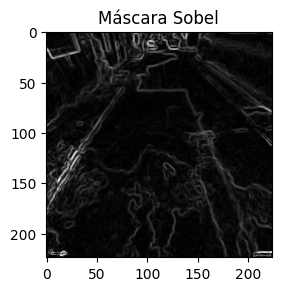

In [77]:
imgs_mask_thresh = []
for mask in imgs_mask:
    sobel_norm = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX)
    imgs_mask_thresh.append(sobel_norm)

imgs_mask_thresh = np.array(imgs_mask_thresh)

plt.subplot(1,2,2)
plt.imshow(imgs_mask_thresh[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()

In [78]:
# --- Normalização ---
X_imgs = np.array(imagens) / 255.0
X_masks = np.array(imgs_mask_thresh) / 255.0
X_masks = np.expand_dims(X_masks, axis=-1)

# --- Labels ---
y = np.array(labels)

# --- 1. Undersampling para balancear ---
classes = np.unique(y)
min_count = min([np.sum(y == c) for c in classes])

X_img_bal = []
X_mask_bal = []
y_bal = []

for c in classes:
    idx = np.where(y == c)[0]
    np.random.shuffle(idx)
    idx_cut = idx[:min_count]  # corta para o mínimo
    X_img_bal.append(X_imgs[idx_cut])
    X_mask_bal.append(X_masks[idx_cut])
    y_bal.append(y[idx_cut])

# Concatenar tudo
X_imgs = np.concatenate(X_img_bal, axis=0)
X_masks = np.concatenate(X_mask_bal, axis=0)
y = np.concatenate(y_bal, axis=0)

# --- 2. One-hot após balancear ---
y = to_categorical(y, num_classes=3)

# --- 3. Divisão treino/val/test ---
X_img_train, X_img_test, X_mask_train, X_mask_test, y_train, y_test = train_test_split(
    X_imgs, X_masks, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)

X_img_train, X_img_val, X_mask_train, X_mask_val, y_train, y_val = train_test_split(
    X_img_train, X_mask_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
)

In [98]:
# Entrada da imagem RGB
input_img = Input(shape=(X_imgs.shape[1], X_imgs.shape[2], 3))

x1 = Conv2D(16, (3,3), activation='relu')(input_img)
x1 = MaxPooling2D((2,2))(x1)
x1 = Conv2D(8, (3,3), activation='relu')(x1)
x1 = MaxPooling2D((2,2))(x1)
x1 = Flatten()(x1)

# Entrada da máscara (1 canal)
input_mask = Input(shape=(X_masks.shape[1], X_masks.shape[2], 1))

x2 = Conv2D(16, (3,3), activation='relu')(input_mask)
x2 = MaxPooling2D((2,2))(x2)
x2 = Conv2D(8, (3,3), activation='relu')(x2)
x2 = MaxPooling2D((2,2))(x2)
x2 = Flatten()(x2)

# Concatenar as duas saídas
merged = Concatenate()([x1, x2])

# Classificação final
dense = Dense(64, activation='relu')(merged)
dense = Dropout(0.5)(dense)
output = Dense(3, activation='softmax')(dense)

# Modelo final
model = Model(inputs=[input_img, input_mask], outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 222, 222,  │        448 │ input_layer_12[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 222, 222,  │        160 │ input_layer_13[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 111, 111,  │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 111, 111,  │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 109, 109,  │      1,160 │ max_pooling2d_24… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 109, 109,  │      1,160 │ max_pooling2d_26… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, 54, 54, 8) │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 54, 54, 8) │          0 │ conv2d_27[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 23328)     │          0 │ max_pooling2d_25… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 23328)     │          0 │ max_pooling2d_27… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 46656)     │          0 │ flatten_12[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │  2,986,048 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        195 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,989,171 (11.40 MB)

 Trainable params: 2,989,171 (11.40 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Callback para salvar o melhor modelo baseado na acurácia de validação
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',   # nome do arquivo
    monitor='val_accuracy',     # métrica a ser monitorada
    mode='max',                 # queremos o maior valor de acurácia
    save_best_only=True,        # salva apenas o melhor
    verbose=0
)

# Treinamento com callback
history = model.fit(
    [X_img_train, X_mask_train],
    y_train,
    validation_data=([X_img_val, X_mask_val], y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint],  # adiciona aqui
    verbose=1
)

loss, acc = model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Test Accuracy: {acc:.2f}")

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3616 - loss: 1.6624

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.3516 - loss: 1.3834 - val_accuracy: 0.4135 - val_loss: 1.0020
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5205 - loss: 0.9580

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.5690 - loss: 0.9087 - val_accuracy: 0.6316 - val_loss: 0.7728
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7059 - loss: 0.7005

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.6824 - loss: 0.7264 - val_accuracy: 0.6617 - val_loss: 0.7177
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7838 - loss: 0.5738

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.7902 - loss: 0.5570 - val_accuracy: 0.7068 - val_loss: 0.6575
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8983 - loss: 0.3642

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.8904 - loss: 0.3726 - val_accuracy: 0.7143 - val_loss: 0.6327
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8822 - loss: 0.3245

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.9093 - loss: 0.3031 - val_accuracy: 0.7444 - val_loss: 0.6184
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.9357 - loss: 0.2169 - val_accuracy: 0.6767 - val_loss: 0.7240
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.9641 - loss: 0.1564 - val_accuracy: 0.7444 - val_loss: 0.7714
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.9792 - loss: 0.0871 - val_accuracy: 0.7444 - val_loss: 0.6409
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.9887 - loss: 0.0665 - val_accuracy: 0.7444 - val_loss: 0.7194
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.9868 - loss: 0.0520 - val_accuracy: 0.7293 - val_loss: 0.7646
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.9943 - loss: 0.0387 - val_accuracy: 0.7444 - val_loss: 0.6890
Epoch 13/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.9962 - loss: 0.0369 - val_accuracy: 0.7293 - 

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.9962 - loss: 0.0300 - val_accuracy: 0.7744 - val_loss: 0.7896
Epoch 16/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 0.7368 - val_loss: 0.8487
Epoch 17/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.9943 - loss: 0.0255 - val_accuracy: 0.7293 - val_loss: 0.9563
Epoch 18/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.9962 - loss: 0.0211 - val_accuracy: 0.7444 - val_loss: 0.7911
Epoch 19/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.9905 - loss: 0.0356 - val_accuracy: 0.7594 - val_loss: 0.7461
Epoch 20/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9955 - loss: 0.0192

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.9981 - loss: 0.0177 - val_accuracy: 0.7820 - val_loss: 0.8438
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7229 - loss: 0.9877
Test Accuracy: 0.72


In [100]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')

loss, acc = best_model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Best Model Test Accuracy: {acc:.2f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7229 - loss: 0.9877
Best Model Test Accuracy: 0.72


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


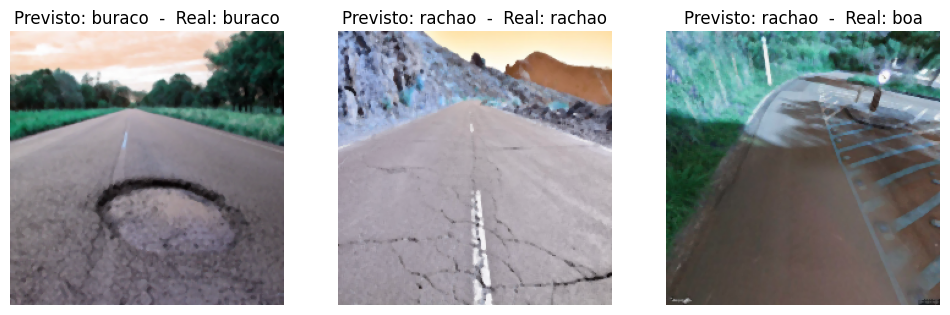

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
class_names = ["buraco", "rachao", "boa"]

# Seleciona uma imagem aleatória de cada classe
indices = []
for c in range(3):
    idxs = np.where(np.argmax(y_test, axis=1) == c)[0]
    idx = np.random.choice(idxs)  # escolha aleatória
    indices.append(idx)

# Loop para plotar
plt.figure(figsize=(12,4))

for i, idx in enumerate(indices):
    img = X_img_test[idx]
    label = y_test[idx]
    if label[0] == 1:
        label = "buraco"
    elif label[1] == 1:
        label = "rachao"
    else:
        label = "boa"
    mask = X_mask_test[idx][..., 0]  # pega canal único da máscara

    # Predição do modelo
    pred = best_model.predict([img[np.newaxis,...], X_mask_test[idx][np.newaxis,...]])
    pred_class = class_names[np.argmax(pred)]

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Previsto: {pred_class}  -  Real: {label}")
    plt.axis('off')


plt.show()


